In [5]:
from pathlib import Path
import sys

import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle

PROJECT_ROOT = Path("/Users/anandadide/Documents/GitHub/VesselAttributesPrediction")
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from vesselattributeprediction.utils import load_geojson_file, load_tiff_image, map_type_id_to_class_id_and_vessel
from vesselattributeprediction.data.data_utils import convert_bbox_dim, scale_image_and_bounding_boxes
from vesselattributeprediction.constants import VESSEL_TYPES_TO_CLASS_ID, CLASS_ID_TO_VESSEL_TYPES
from vesselattributeprediction.data.dataset import xViewDataset
from vesselattributeprediction.model.cargoPredictorModel import CargoPredictorModel
from vesselattributeprediction.model.vesselDetectorModel import VesselDetectorModel
from vesselattributeprediction.evaluation import EvaluationMetrics


In [6]:
# Global data parameters
root_data_dir = PROJECT_ROOT / "data"
annotation_filepath = root_data_dir / "xView_train.geojson"
img_dir = root_data_dir / "train_images"

# xView Dataset overview

## Tiff optical satellite image

Images are of shape:
(3149, 3915, 3)


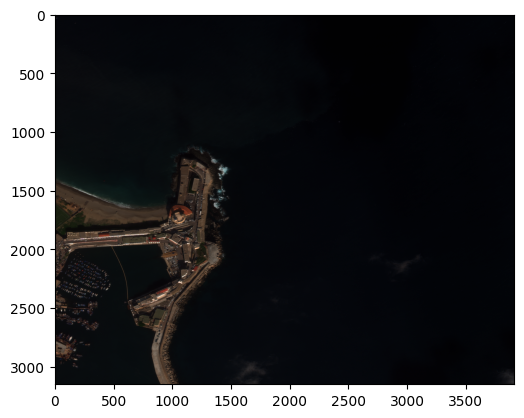

In [14]:
# Load an example image tif
image_filename = img_dir / "1472.tif"

image = load_tiff_image(image_filename)

# Image dimensions
print("Images are of shape:")
print(image.shape)

plt.imshow(image)
plt.show()

## Geojson annotations file

In [15]:
# Load annotations
annotations_dict = load_geojson_file(annotation_filepath)
annotations_dict["features"][0:2]

[{'type': 'Feature',
  'properties': {'bounds_imcoords': '2712,1145,2746,1177',
   'edited_by': 'wwoscarbecerril',
   'cat_id': '1040010028371A00',
   'type_id': 73,
   'ingest_time': '2017/07/24 12:49:09.118+00',
   'index_right': 2356,
   'image_id': '2355.tif',
   'point_geom': '0101000020E6100000616E4E6406A256C03BE6ADA0D6212D40',
   'feature_id': 374410,
   'grid_file': 'Grid2.shp'},
  'geometry': {'type': 'Polygon',
   'coordinates': [[[-90.53169885094464, 14.56603647302396],
     [-90.53169885094464, 14.56614473506768],
     [-90.53158140073565, 14.56614473506768],
     [-90.53158140073565, 14.56603647302396],
     [-90.53169885094464, 14.56603647302396]]]}},
 {'type': 'Feature',
  'properties': {'bounds_imcoords': '2720,2233,2760,2288',
   'edited_by': 'wwoscarbecerril',
   'cat_id': '1040010028371A00',
   'type_id': 73,
   'ingest_time': '2017/07/24 17:26:05.701+00',
   'index_right': 2356,
   'image_id': '2355.tif',
   'point_geom': '0101000020E6100000042D0CC705A256C0004F7071E

In [22]:
# Annotations are under "features"
example_annotation = annotations_dict["features"][0]

# Object annotations are stored under "properties"
annotation_properties = example_annotation["properties"].keys()

# Georeferenced coordinated are stored under "geometry"/"coordinates" as Polygons
georeferenced_coordinate = example_annotation["geometry"]

print("Property annotations available:")
print(f"{annotation_properties}")
print("")

print("Georeferenced coordinates available:")
print(georeferenced_coordinate["coordinates"][0])

Property annotations available:
dict_keys(['bounds_imcoords', 'edited_by', 'cat_id', 'type_id', 'ingest_time', 'index_right', 'image_id', 'point_geom', 'feature_id', 'grid_file'])

Georeferenced coordinates available:
[[-90.53169885094464, 14.56603647302396], [-90.53169885094464, 14.56614473506768], [-90.53158140073565, 14.56614473506768], [-90.53158140073565, 14.56603647302396], [-90.53169885094464, 14.56603647302396]]


## Preprocessed and scaled datasets

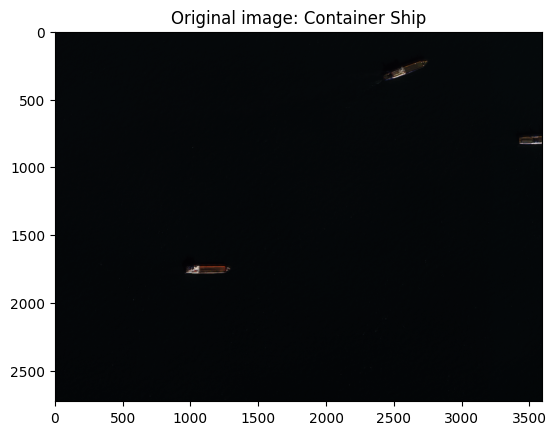

In [4]:
# Load original image and bbox dimensions
img_id = "2268.tif"

ori_img = load_tiff_image(img_dir / img_id)
ori_bbox = None
vessel_type = None
for annotation in annotations_dict["features"]:
    if annotation["properties"]["image_id"] == img_id:
        bbox_dim_str = annotation["properties"]["bounds_imcoords"]
        ori_bbox = convert_bbox_dim(bbox_dim_str)
        _, vessel_type = map_type_id_to_class_id_and_vessel(annotation["properties"]["type_id"])
        break

plt.imshow(ori_img)
plt.title(f"Original image: {vessel_type}")
plt.show()

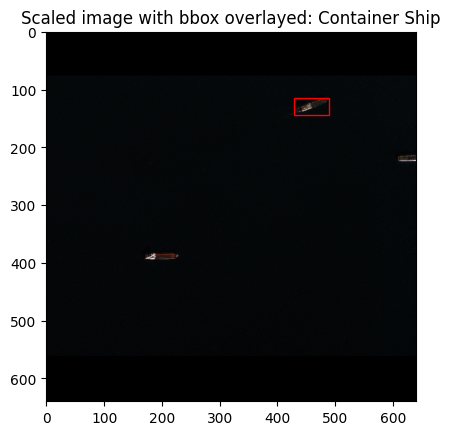

In [5]:
# Scale image/bbox for model preparation
scaled_image, scaled_bbox = scale_image_and_bounding_boxes(ori_img, ori_bbox)
image_to_plot = scaled_image.numpy()

x_min, y_min, x_max, y_max = scaled_bbox.numpy().astype(int)[0]
bbox_rect = patches.Rectangle(
    (x_min, y_min),
    x_max - x_min,
    y_max - y_min,
    linewidth=1,
    edgecolor="red",
    facecolor="none",
)

fig, ax = plt.subplots()
ax.imshow(image_to_plot)
ax.add_patch(bbox_rect)
plt.title(f"Scaled image with bbox overlayed: {vessel_type}")

plt.show()


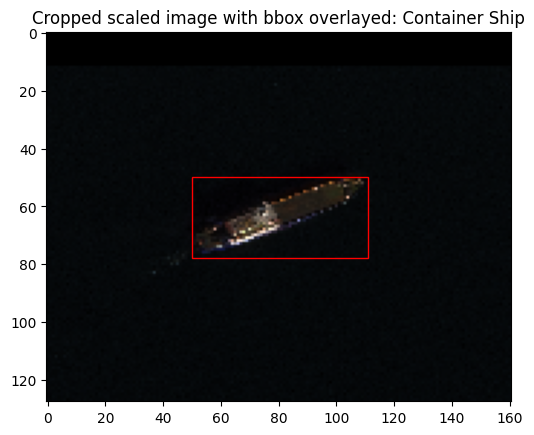

In [6]:
# Cropped scaled image with bbox overlayed
padding = 50
image_height, image_width = image_to_plot.shape[:2]

crop_xmin = max(0, x_min - padding)
crop_ymin = max(0, y_min - padding)
crop_xmax = min(image_width, x_max + padding)
crop_ymax = min(image_height, y_max + padding)

cropped_image = image_to_plot[
    crop_ymin:crop_ymax,
    crop_xmin:crop_xmax,
]
cropped_bbox_xmin = x_min - crop_xmin
cropped_bbox_ymin = y_min - crop_ymin
cropped_bbox_xmax = x_max - crop_xmin
cropped_bbox_ymax = y_max - crop_ymin

# Visualize
fig, ax = plt.subplots()
ax.imshow(cropped_image)
bbox_rect = patches.Rectangle(
    (cropped_bbox_xmin, cropped_bbox_ymin),
    cropped_bbox_xmax - cropped_bbox_xmin,
    cropped_bbox_ymax - cropped_bbox_ymin,
    linewidth=1,
    edgecolor="red",
    facecolor="none",
)
ax.add_patch(bbox_rect)
plt.title(f"Cropped scaled image with bbox overlayed: {vessel_type}")

plt.show()

# CLIP cargo status example

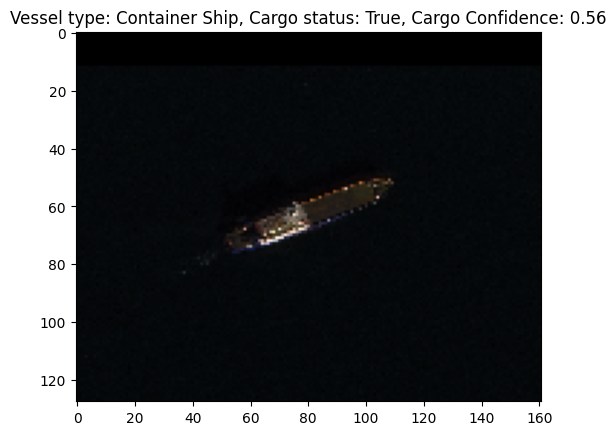

In [8]:
# Example vessel crop + ground truth vessel type
vessel_crop = cropped_image
vessel_type = "Container Ship"

# Use CLIP to run cargo status prediction
cargo_predictor = CargoPredictorModel()
cargo_status, cargo_confidence = cargo_predictor.predict_vessel_cargo_status(vessel_crop, vessel_type)

plt.imshow(vessel_crop)
plt.title(
    f"Vessel type: {vessel_type}, Cargo status: {cargo_status}, "
    f"Cargo Confidence: {cargo_confidence:.2f}"
)
plt.show()

# Process datasets

In [ ]:
# Initialize and process xView datasets
dataset_class = xViewDataset()
dataset_class.process_xviewdataset_workflow()

In [4]:
def count_objects_by_class(dataset):
    """
    Returns number of object annotations by Class ID in dataset.
    """
    counts = Counter()

    for batch in dataset:
        class_ids = batch["bounding_boxes"]["classes"]
        counts.update(class_ids.flat_values.numpy().astype(int))

    return counts

# Class % by dataset split
train_data = dataset_class._processed_datasets.training
val_data = dataset_class._processed_datasets.validation
test_data = dataset_class._processed_datasets.testing
split_dataset = {
    "Training": train_data,
    "Validation": val_data,
    "Testing": test_data,
}


bbox_counts = {
    split_name: count_objects_by_class(split_data)
    for split_name, split_data in split_dataset.items()
}
class_ids = sorted(list(VESSEL_TYPES_TO_CLASS_ID.values()))

bbox_count_df = pd.DataFrame(
    {
        split_name: [counts.get(class_id, 0) for class_id in class_ids]
        for split_name, counts in bbox_counts.items()
    },
    index=class_ids,
)
bbox_count_df.index.name = "Class ID"

print(bbox_count_df)



2026-06-23 21:49:07.704481: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-23 21:49:09.897845: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


          Training  Validation  Testing
Class ID                               
0              708         156      221
1             1735         245      533
2              680         142      153
3              266          36       63
4              219          18       76
5              902         343      242
6              220          52       86
7              492         101      177
8              285          57      192
9               94           9       23


# Train vessel detector model


In [5]:
# Initialize model
vessel_detector_model = VesselDetectorModel()

train_data = dataset_class._processed_datasets.training
val_data = dataset_class._processed_datasets.validation
vessel_detector_model.train_model_with_transfer_learning(train_data, val_data)

Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 289s 730ms/step - box_loss: 3.3803 - class_loss: 473.8029 - loss: 477.7885 - val_box_loss: 1.1040 - val_class_loss: 181.6139 - val_loss: 182.7178
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 286s 737ms/step - box_loss: 2.9234 - class_loss: 22.4671 - loss: 25.4127 - val_box_loss: 1.1135 - val_class_loss: 42.5097 - val_loss: 43.6232
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 288s 742ms/step - box_loss: 2.7486 - class_loss: 6.8206 - loss: 9.5766 - val_box_loss: 1.0569 - val_class_loss: 19.6728 - val_loss: 20.7297
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 290s 748ms/step - box_loss: 2.6264 - class_loss: 3.7582 - loss: 6.3877 - val_box_loss: 1.0218 - val_class_loss: 10.4924 - val_loss: 11.5142
Epoch 5/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 287s 741ms/step - box_loss: 2.4413 - class_loss: 2.2659 - loss: 4.7075 - val_box_loss: 0.9742 - val_class_loss: 6.6370 - val_loss: 7.6112
Epoch 6/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 292s 752ms/step - box_loss: 2.3276 - class_loss: 1.504

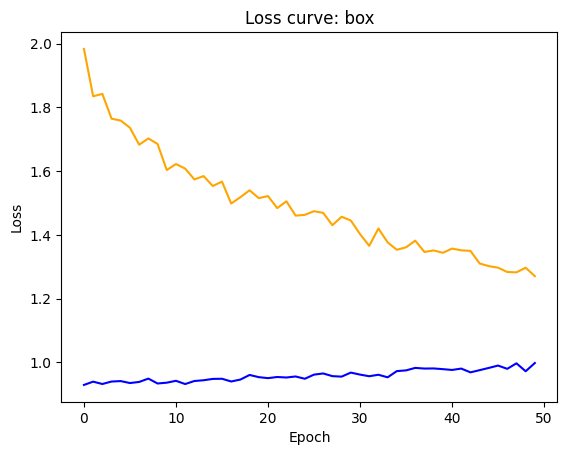

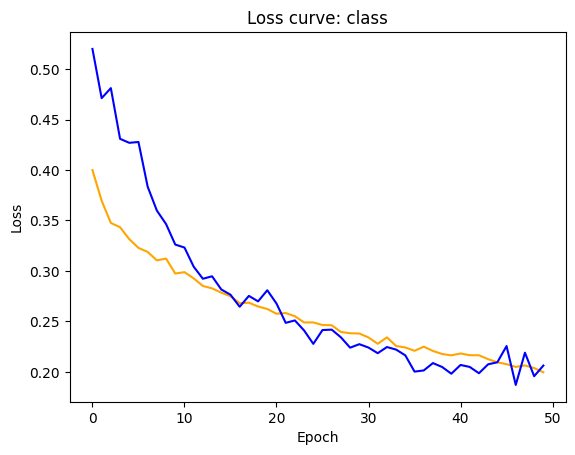

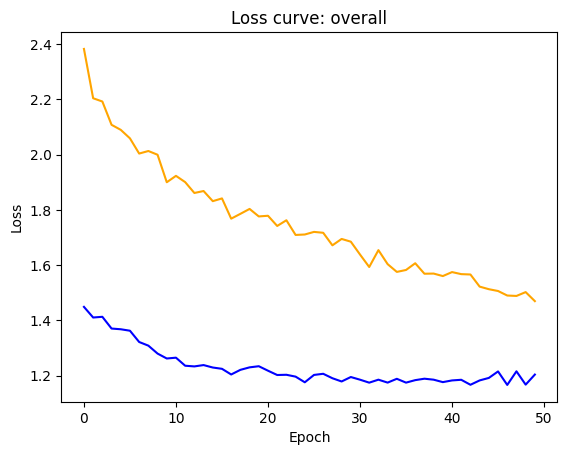

In [6]:
# Loss curves
training_json_file = "detector_model_training/detector_training_history.json"
with open(training_json_file, 'r') as file:
    training_json = json.load(file)

loss_types = ["box", "class", "overall"]
for type in loss_types:
    if type == "overall":
            train_loss = training_json['loss']
            val_loss = training_json['val_loss']
    else:
        train_loss = training_json[f'{type}_loss']
        val_loss = training_json[f'val_{type}_loss']

    plt.plot(range(len(train_loss)), train_loss, color = "orange", label = "training")
    plt.plot(range(len(val_loss)), val_loss, color = "blue", label = "validation")
    plt.title(f"Loss curve: {type}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.show()

# Evaluation

In [4]:
# Collect predictions
best_model_file = "detector_model_training/vessel_detector_model.keras"
evaluator = EvaluationMetrics()
test_output = evaluator.test_model(test_dataset=dataset_class._processed_datasets.testing, model_keras_datafile=best_model_file)
test_results_dict = evaluator.create_test_results_dict(test_output)

2026-06-24 00:54:34.020777: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# Calculate metrics
evaluation_metrics_results = evaluator.calculate_vessel_detector_metrics(test_results_dict)
evaluation_metrics_results.columns = list(VESSEL_TYPES_TO_CLASS_ID.keys())
evaluation_metrics_results

,Maritime Vessel,Motorboat,Sailboat,Tugboat,Barge,Fishing Vessel,Ferry,Yacht,Container Ship,Oil Tanker
precision,0.125000,0.394464,0.0,0.098592,0.000000,0.090909,0.095238,0.538462,0.370370,0.400000
recall,0.013575,0.213884,0.0,0.111111,0.000000,0.008264,0.023256,0.079096,0.104167,0.173913
false_positive_rate,0.054830,0.462963,0.0,0.158025,0.014778,0.055249,0.048718,0.036364,0.085642,0.014778
bbox_mAP,0.000937,0.015895,0.0,0.017196,0.000000,0.000000,0.001696,0.018145,0.014227,0.033954


In [8]:
# Additional stats in terms of raw numbers
classification_matrices = evaluator.get_classification_matrix_by_class(test_results_dict)
for class_id in classification_matrices.keys():
    vessel_class = CLASS_ID_TO_VESSEL_TYPES[class_id]
    matrix = classification_matrices[class_id]

    print(f"Vessel class: {vessel_class}")
    print(matrix)
    

Vessel class: Maritime Vessel
{'TP': 3, 'FP': 21, 'FN': 218}
Vessel class: Motorboat
{'TP': 114, 'FP': 175, 'FN': 419}
Vessel class: Sailboat
{'TP': 0, 'FP': 0, 'FN': 153}
Vessel class: Tugboat
{'TP': 7, 'FP': 64, 'FN': 56}
Vessel class: Barge
{'TP': 0, 'FP': 6, 'FN': 76}
Vessel class: Fishing Vessel
{'TP': 2, 'FP': 20, 'FN': 240}
Vessel class: Ferry
{'TP': 2, 'FP': 19, 'FN': 84}
Vessel class: Yacht
{'TP': 14, 'FP': 12, 'FN': 163}
Vessel class: Container Ship
{'TP': 20, 'FP': 34, 'FN': 172}
Vessel class: Oil Tanker
{'TP': 4, 'FP': 6, 'FN': 19}


# Investigation

In [9]:
# Helper functions for visualizing predictions
def draw_box(ax, box, color, label):
    x_min, y_min, x_max, y_max = box
    ax.add_patch(
        Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor=color,
            linewidth=2,
            label=label,
        )
    )


def unscale_box(scaled_box, image_shape):
    target_h, target_w = 640, 640
    image_h, image_w = image_shape[:2]
    scale = min(target_h / image_h, target_w / image_w)
    scaled_h, scaled_w = round(image_h * scale), round(image_w * scale)
    offset_x = (target_w - scaled_w) // 2
    offset_y = (target_h - scaled_h) // 2

    box = np.asarray(scaled_box, dtype=np.float32).copy()
    box[[0, 2]] = (box[[0, 2]] - offset_x) / scale
    box[[1, 3]] = (box[[1, 3]] - offset_y) / scale
    return box

## Visualize True Predictions

Visualizing a correctly predicted Tugboat...


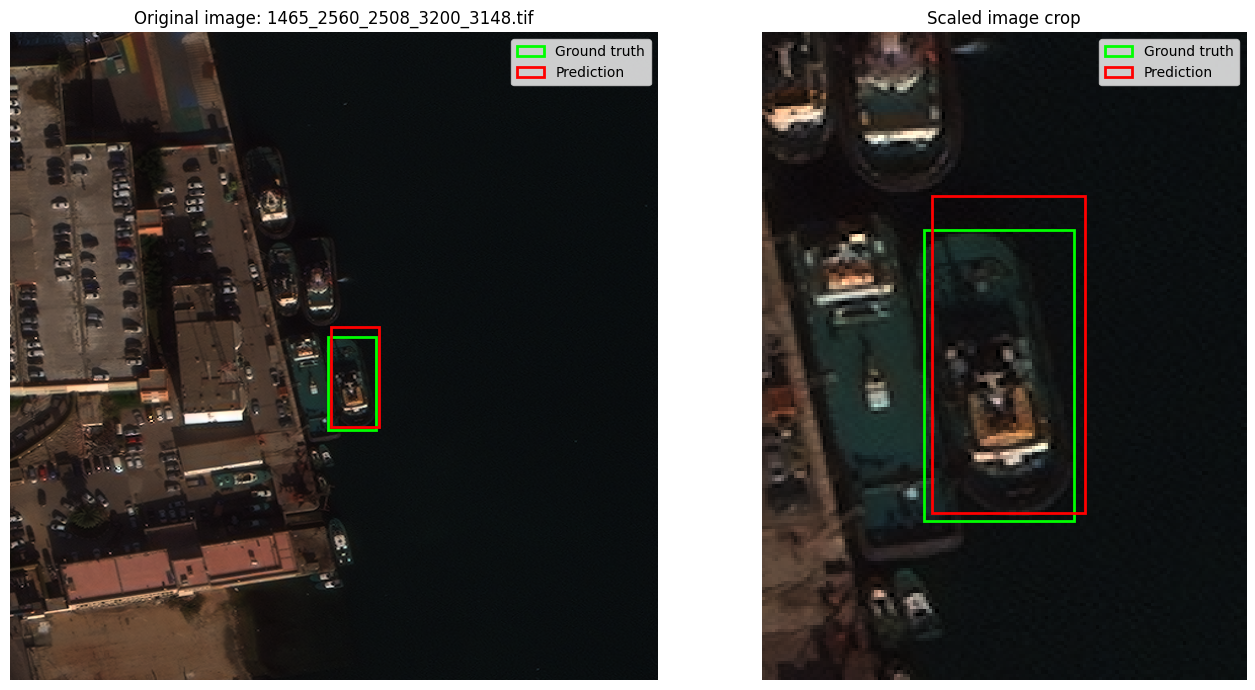

In [10]:
# Visualize TPs for specific class
vessel_class = "Tugboat"
MARITIME_CLASS_ID = VESSEL_TYPES_TO_CLASS_ID[vessel_class]
PAD = 50
print(f"Visualizing a correctly predicted {vessel_class}...")

matched = test_results_dict["matched_predictions"]
tp_indexes = np.where(
    (matched["true_classes"] == MARITIME_CLASS_ID)
    & (matched["predicted_classes"] == MARITIME_CLASS_ID)
)[0]

if len(tp_indexes) == 0:
    raise ValueError("No Maritime Vessel true-positive predictions found in test_results_dict.")

tp_index = tp_indexes[0]
scaled_gt_box = matched["true_bboxes"][tp_index]
scaled_pred_box = matched["predicted_bboxes"][tp_index]

# Rebuild tiled testing metadata in the same order used by process_xviewdataset_workflow().
testing_tiles = dataset_class.slice_dataset(
    dataset_class._ori_datasets.testing,
    "testing",
)
test_image_paths = list(testing_tiles.keys())
test_annotations = list(testing_tiles.values())

image_index = next(
    image_index
    for image_index, boxes in enumerate(evaluator._true_boxes)
    if np.any(np.all(np.isclose(boxes, scaled_gt_box), axis=1))
)

image_path = test_image_paths[image_index]
image = load_tiff_image(image_path)

original_gt_box = unscale_box(scaled_gt_box, image.shape)
original_pred_box = unscale_box(scaled_pred_box, image.shape)

scaled_image, _ = scale_image_and_bounding_boxes(
    image,
    test_annotations[image_index]["boxes"],
)
scaled_image = scaled_image.numpy()

crop_box = np.vstack([scaled_gt_box, scaled_pred_box])
x_min, y_min = np.floor(crop_box[:, :2].min(axis=0) - PAD).astype(int)
x_max, y_max = np.ceil(crop_box[:, 2:].max(axis=0) + PAD).astype(int)
x_min, y_min = np.maximum([x_min, y_min], 0)
x_max, y_max = np.minimum([x_max, y_max], scaled_image.shape[1::-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image)
draw_box(axes[0], original_gt_box, "lime", "Ground truth")
draw_box(axes[0], original_pred_box, "red", "Prediction")
axes[0].set_title(f"Original image: {image_path.name}")
axes[0].legend()

axes[1].imshow(scaled_image[y_min:y_max, x_min:x_max])
draw_box(axes[1], scaled_gt_box - [x_min, y_min, x_min, y_min], "lime", "Ground truth")
draw_box(axes[1], scaled_pred_box - [x_min, y_min, x_min, y_min], "red", "Prediction")
axes[1].set_title("Scaled image crop")
axes[1].legend()

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize False Predictions

Visualizing a falsely predicted Motorboat...


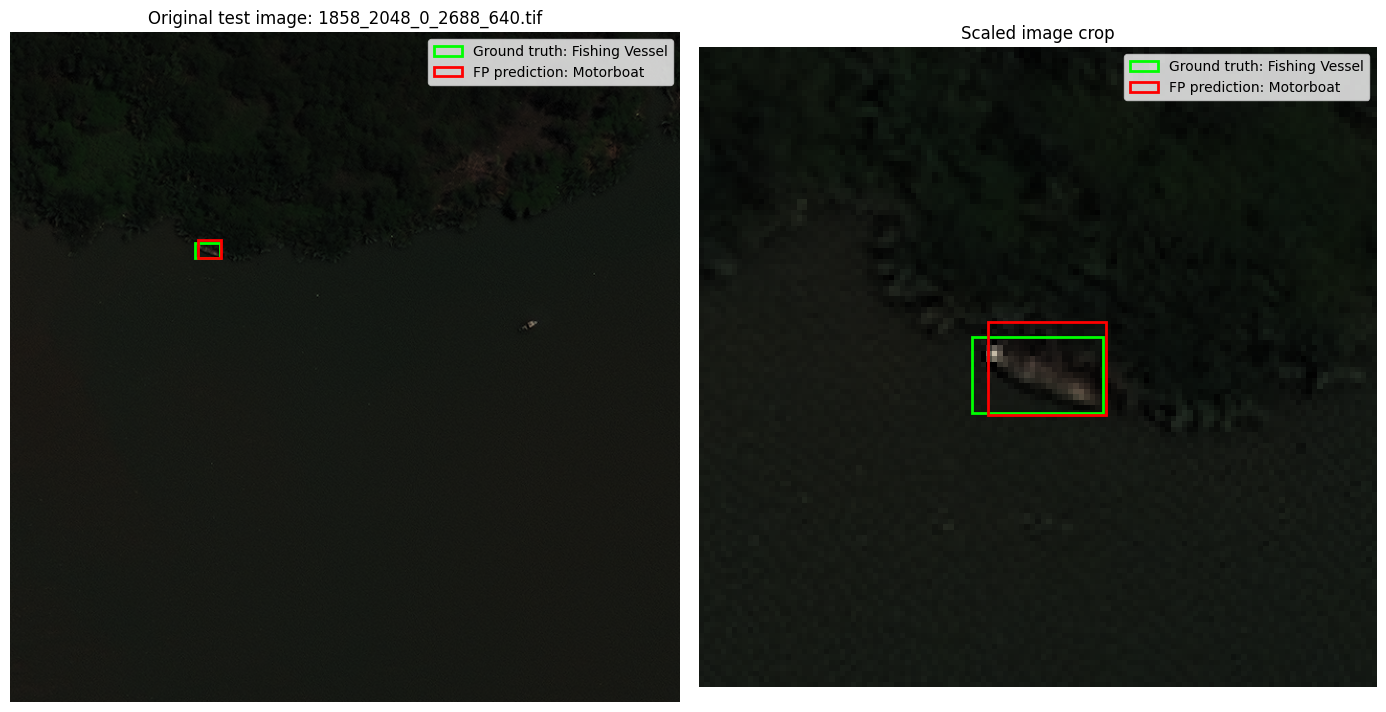

In [11]:
CLASS_NAME = "Motorboat"
CLASS_ID = VESSEL_TYPES_TO_CLASS_ID[CLASS_NAME]
PAD = 50
print(f"Visualizing a falsely predicted {CLASS_NAME}...")

testing_tiles = dataset_class.slice_dataset(
    dataset_class._ori_datasets.testing,
    "testing",
)
test_image_paths = list(testing_tiles.keys())
test_annotations = list(testing_tiles.values())

matched = test_results_dict["matched_predictions"]
unmatched = test_results_dict["unmatched_predictions"]

matched_fp_indexes = np.where(
    (matched["predicted_classes"] == CLASS_ID)
    & (matched["true_classes"] != CLASS_ID)
)[0]

if len(matched_fp_indexes) > 0:
    fp_index = matched_fp_indexes[0]
    scaled_gt_box = matched["true_bboxes"][fp_index]
    scaled_pred_box = matched["predicted_bboxes"][fp_index]
    true_class_id = int(matched["true_classes"][fp_index])
    true_class_name = CLASS_ID_TO_VESSEL_TYPES[true_class_id]

    image_index = next(
        image_index
        for image_index, boxes in enumerate(evaluator._true_boxes)
        if np.any(np.all(np.isclose(boxes, scaled_gt_box), axis=1))
    )
else:
    unmatched_fp_indexes = np.where(unmatched["predicted_classes"] == CLASS_ID)[0]
    if len(unmatched_fp_indexes) == 0:
        raise ValueError(f"No false-positive predictions found for {CLASS_NAME}.")

    fp_index = unmatched_fp_indexes[0]
    scaled_gt_box = None
    scaled_pred_box = unmatched["predicted_bboxes"][fp_index]
    true_class_name = "No matched ground truth"

    image_index = next(
        image_index
        for image_index, boxes in enumerate(test_output["boxes"])
        if np.any(np.all(np.isclose(boxes, scaled_pred_box), axis=1))
    )

image_path = test_image_paths[image_index]
image = load_tiff_image(image_path)

scaled_image, _ = scale_image_and_bounding_boxes(
    image,
    test_annotations[image_index]["boxes"],
)
scaled_image = scaled_image.numpy()

original_pred_box = unscale_box(scaled_pred_box, image.shape)
original_gt_box = None if scaled_gt_box is None else unscale_box(scaled_gt_box, image.shape)

boxes_to_crop = [scaled_pred_box] if scaled_gt_box is None else [scaled_gt_box, scaled_pred_box]
crop_box = np.vstack(boxes_to_crop)

x_min, y_min = np.floor(crop_box[:, :2].min(axis=0) - PAD).astype(int)
x_max, y_max = np.ceil(crop_box[:, 2:].max(axis=0) + PAD).astype(int)
x_min, y_min = np.maximum([x_min, y_min], 0)
x_max, y_max = np.minimum([x_max, y_max], scaled_image.shape[1::-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image)
if original_gt_box is not None:
    draw_box(axes[0], original_gt_box, "lime", f"Ground truth: {true_class_name}")
draw_box(axes[0], original_pred_box, "red", f"FP prediction: {CLASS_NAME}")
axes[0].set_title(f"Original test image: {image_path.name}")
axes[0].legend()

axes[1].imshow(scaled_image[y_min:y_max, x_min:x_max])
if scaled_gt_box is not None:
    draw_box(
        axes[1],
        scaled_gt_box - [x_min, y_min, x_min, y_min],
        "lime",
        f"Ground truth: {true_class_name}",
    )
draw_box(
    axes[1],
    scaled_pred_box - [x_min, y_min, x_min, y_min],
    "red",
    f"FP prediction: {CLASS_NAME}",
)
axes[1].set_title("Scaled image crop")
axes[1].legend()

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize a non-existent vessel object

Visualizing a prediction that is not a vessel object...


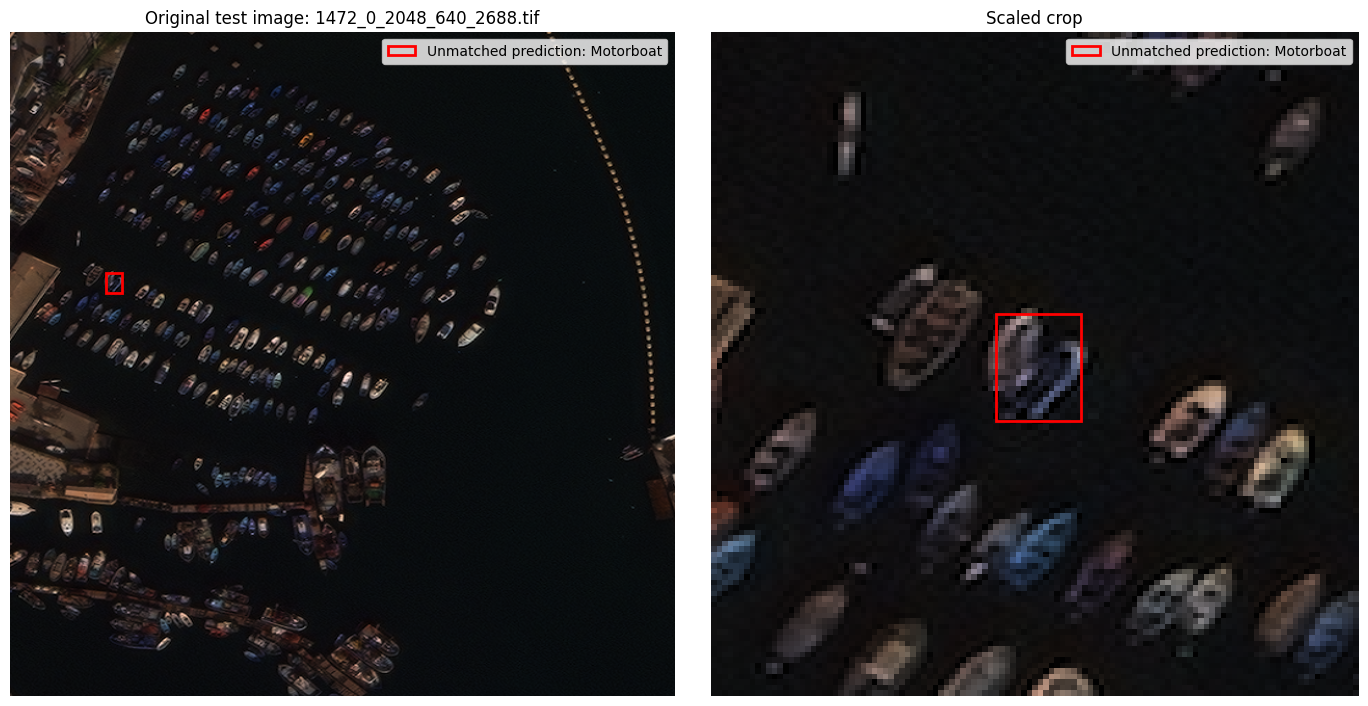

In [25]:
PAD = 50
UNMATCHED_INDEX = 20
print("Visualizing a prediction that is not a vessel object...")

testing_tiles = dataset_class.slice_dataset(
    dataset_class._ori_datasets.testing,
    "testing",
)
test_image_paths = list(testing_tiles.keys())
test_annotations = list(testing_tiles.values())

unmatched = test_results_dict["unmatched_predictions"]

if len(unmatched["predicted_bboxes"]) == 0:
    raise ValueError("No unmatched predictions found.")

scaled_pred_box = unmatched["predicted_bboxes"][UNMATCHED_INDEX]
predicted_class_id = int(unmatched["predicted_classes"][UNMATCHED_INDEX])
predicted_class_name = CLASS_ID_TO_VESSEL_TYPES[predicted_class_id]

image_index = next(
    image_index
    for image_index, boxes in enumerate(test_output["boxes"])
    if np.any(np.all(np.isclose(boxes, scaled_pred_box), axis=1))
)

image_path = test_image_paths[image_index]
image = load_tiff_image(image_path)

scaled_image, _ = scale_image_and_bounding_boxes(
    image,
    test_annotations[image_index]["boxes"],
)
scaled_image = scaled_image.numpy()

original_pred_box = unscale_box(scaled_pred_box, image.shape)

x_min, y_min = np.floor(scaled_pred_box[:2] - PAD).astype(int)
x_max, y_max = np.ceil(scaled_pred_box[2:] + PAD).astype(int)
x_min, y_min = np.maximum([x_min, y_min], 0)
x_max, y_max = np.minimum([x_max, y_max], scaled_image.shape[1::-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(image)
draw_box(axes[0], original_pred_box, "red", f"Unmatched prediction: {predicted_class_name}")
axes[0].set_title(
    f"Original test image: {image_path.name}"
)
axes[0].legend()

axes[1].imshow(scaled_image[y_min:y_max, x_min:x_max])
draw_box(
    axes[1],
    scaled_pred_box - [x_min, y_min, x_min, y_min],
    "red",
    f"Unmatched prediction: {predicted_class_name}",
)
axes[1].set_title(
    f"Scaled crop"
)
axes[1].legend()

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

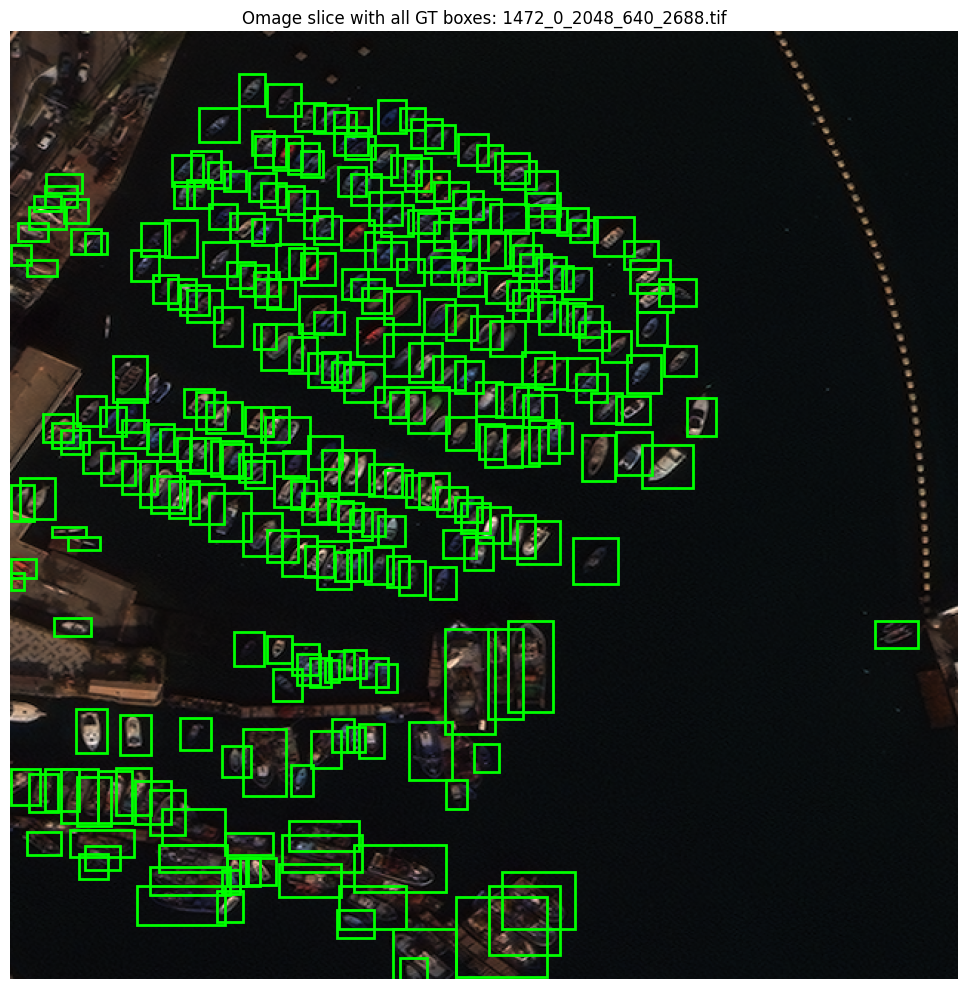

In [32]:
# Visualize all available gt bboxes
PAD = 50

gt_boxes = np.asarray(test_annotations[image_index]["boxes"], dtype=np.float32)
gt_classes = np.asarray(test_annotations[image_index]["classes"], dtype=int)

source_image_id, tile_xmin, tile_ymin, tile_xmax, tile_ymax = image_path.stem.split("_")
tile_xmin, tile_ymin, tile_xmax, tile_ymax = map(
    int,
    [tile_xmin, tile_ymin, tile_xmax, tile_ymax],
)

source_image = load_tiff_image(img_dir / f"{source_image_id}.tif")
source_slice = source_image[tile_ymin:tile_ymax, tile_xmin:tile_xmax]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(source_slice)

for gt_box, class_id in zip(gt_boxes, gt_classes):
    draw_box(
        ax,
        gt_box,
        "lime",
        f"GT: {CLASS_ID_TO_VESSEL_TYPES[int(class_id)]}",
    )

ax.set_title(f"Omage slice with all GT boxes: {image_path.name}")
ax.axis("off")
plt.tight_layout()
plt.show()